# Notebook 1 — Exploration et Preparation des donnees

**Cours** : Forage des Donnees 8INF436 — UQAC Hiver 2026
**Dataset** : Base Telecom 2019-12 (churn prediction)
**Variable cible** : `FLAG_RESILIATION` (0 = client actif, 1 = resilie)

---

## Table des matieres
1. Chargement et apercu
2. Analyse exploratoire (EDA)
3. Gestion des valeurs manquantes
4. Ingenierie des attributs
5. Encodage des variables categoriques
6. Gestion du desequilibre de classes (SMOTE)
7. Normalisation
8. Sauvegarde des donnees prepares

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
from pathlib import Path

# Chemins
ROOT = Path('..').resolve()
DATA_RAW  = ROOT / 'data' / 'raw'  / 'base_telecom_2019_12.csv'
DATA_PROC = ROOT / 'data' / 'processed'
DATA_PROC.mkdir(exist_ok=True)

print(f"Dataset : {DATA_RAW}")
print(f"Sortie  : {DATA_PROC}")

Dataset : /home/as/projet_forage_8INF436/data/raw/base_telecom_2019_12.csv
Sortie  : /home/as/projet_forage_8INF436/data/processed


## 1. Chargement et apercu initial

In [2]:
# Lecture avec encodage latin-1 (accents francais) et separateur point-virgule
df = pd.read_csv(DATA_RAW, sep=';', encoding='latin-1', low_memory=False)

print(f"Dimensions : {df.shape[0]:,} lignes  x  {df.shape[1]} colonnes")
df.head(3)

Dimensions : 46,842 lignes  x  42 colonnes


,ID_CLIENT,FLAG_RESILIATION,DATE_NAISSANCE,SEXE,CSP,CODE_POSTAL,TAILLE_VILLE,TYPE_VILLE,REVENU_MOYEN_VILLE,DATE_ACTIVATION,...,FLAG_APPELS_VERS_INTERNATIONAL,FLAG_APPELS_DEPUIS_INTERNATIONAL,FLAG_APPELS_NUMEROS_SPECIAUX,NB_SMS_M6,NB_SMS_M5,NB_SMS_M4,NB_SMS_M3,NB_SMS_M2,NB_SMS_M1,SEGMENT
0,ID_197510345046,1,24/09/1978,Féminin,Sans emploi,78160,16715.0,Urbaine,24035.0,16/04/2017,...,1,0,0,13,11,10,8.0,7,5,B
1,ID_335550354857,1,20/10/1978,Masculin,Cadre,59400,515.0,Péri-urbaine,14152.0,09/11/2015,...,0,0,0,6,4,3,2.0,0,0,B
2,ID_758842931436,0,02/03/2000,Masculin,Employé,02600,9839.0,Rurale,13648.0,27/10/2019,...,1,0,1,379,359,335,362.0,353,368,A


In [3]:
print("=== Types de colonnes ===")
print(df.dtypes.value_counts())
print()
print("=== Premiers types par colonne ===")
df.dtypes

=== Types de colonnes ===
int64      22
str        15
float64     5
Name: count, dtype: int64

=== Premiers types par colonne ===


ID_CLIENT                               str
FLAG_RESILIATION                      int64
DATE_NAISSANCE                          str
SEXE                                    str
CSP                                     str
CODE_POSTAL                             str
TAILLE_VILLE                        float64
TYPE_VILLE                              str
REVENU_MOYEN_VILLE                  float64
DATE_ACTIVATION                         str
ENSEIGNE                                str
MODE_PAIEMENT                           str
DUREE_OFFRE_INIT                    float64
DUREE_OFFRE                         float64
NB_MIGRATIONS                         int64
FLAG_MIGRATION_HAUSSE                 int64
FLAG_MIGRATION_BAISSE                 int64
NB_SERVICES                           int64
FLAG_PERSONNALISATION_REPONDEUR       int64
FLAG_TELECHARGEMENT_SONNERIE          int64
TELEPHONE_INIT                          str
TELEPHONE                               str
DATE_FIN_ENGAGEMENT             

In [4]:
print("=== Valeurs manquantes (%) ===")
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({'N manquants': miss, '% manquants': miss_pct})
miss_df = miss_df[miss_df['N manquants'] > 0].sort_values('% manquants', ascending=False)
print(miss_df.to_string())

=== Valeurs manquantes (%) ===
                           N manquants  % manquants
DATE_DERNIER_REENGAGEMENT        22360        47.73
TAILLE_VILLE                      3636         7.76
TYPE_VILLE                        1992         4.25
REVENU_MOYEN_VILLE                1992         4.25
DATE_FIN_ENGAGEMENT                635         1.36
NB_SMS_M3                          443         0.95
DATE_NAISSANCE                      44         0.09
SEXE                                 7         0.01


## 2. Analyse exploratoire (EDA)

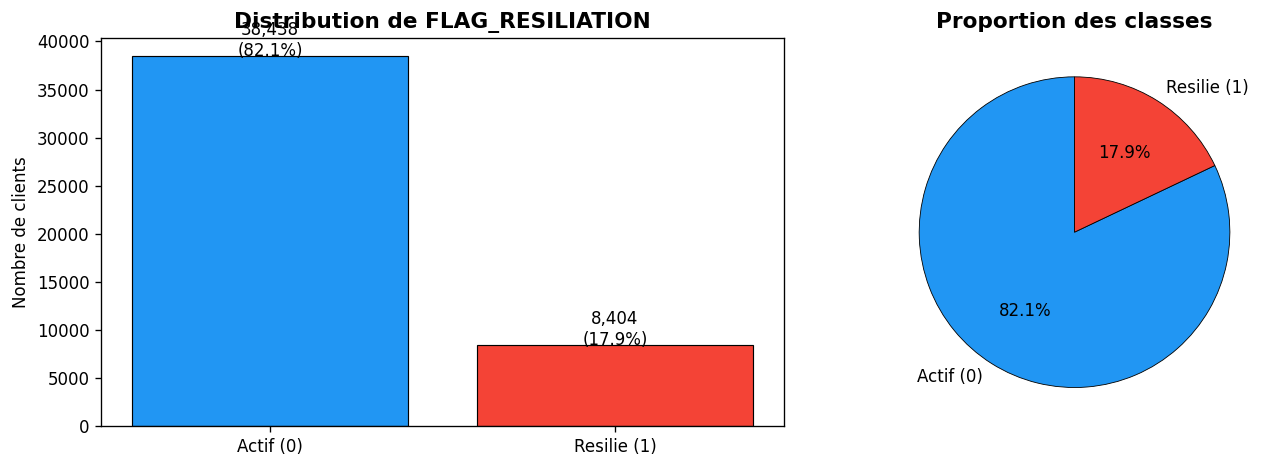

Ratio desequilibre : 4.57:1


In [5]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['FLAG_RESILIATION'].value_counts()
labels = ['Actif (0)', 'Resilie (1)']
colors = ['#2196F3', '#F44336']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Distribution de FLAG_RESILIATION', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'black','linewidth':0.5})
axes[1].set_title('Proportion des classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'distribution_cible.png',
            bbox_inches='tight')
plt.show()
print(f"Ratio desequilibre : {counts[0]/counts[1]:.2f}:1")

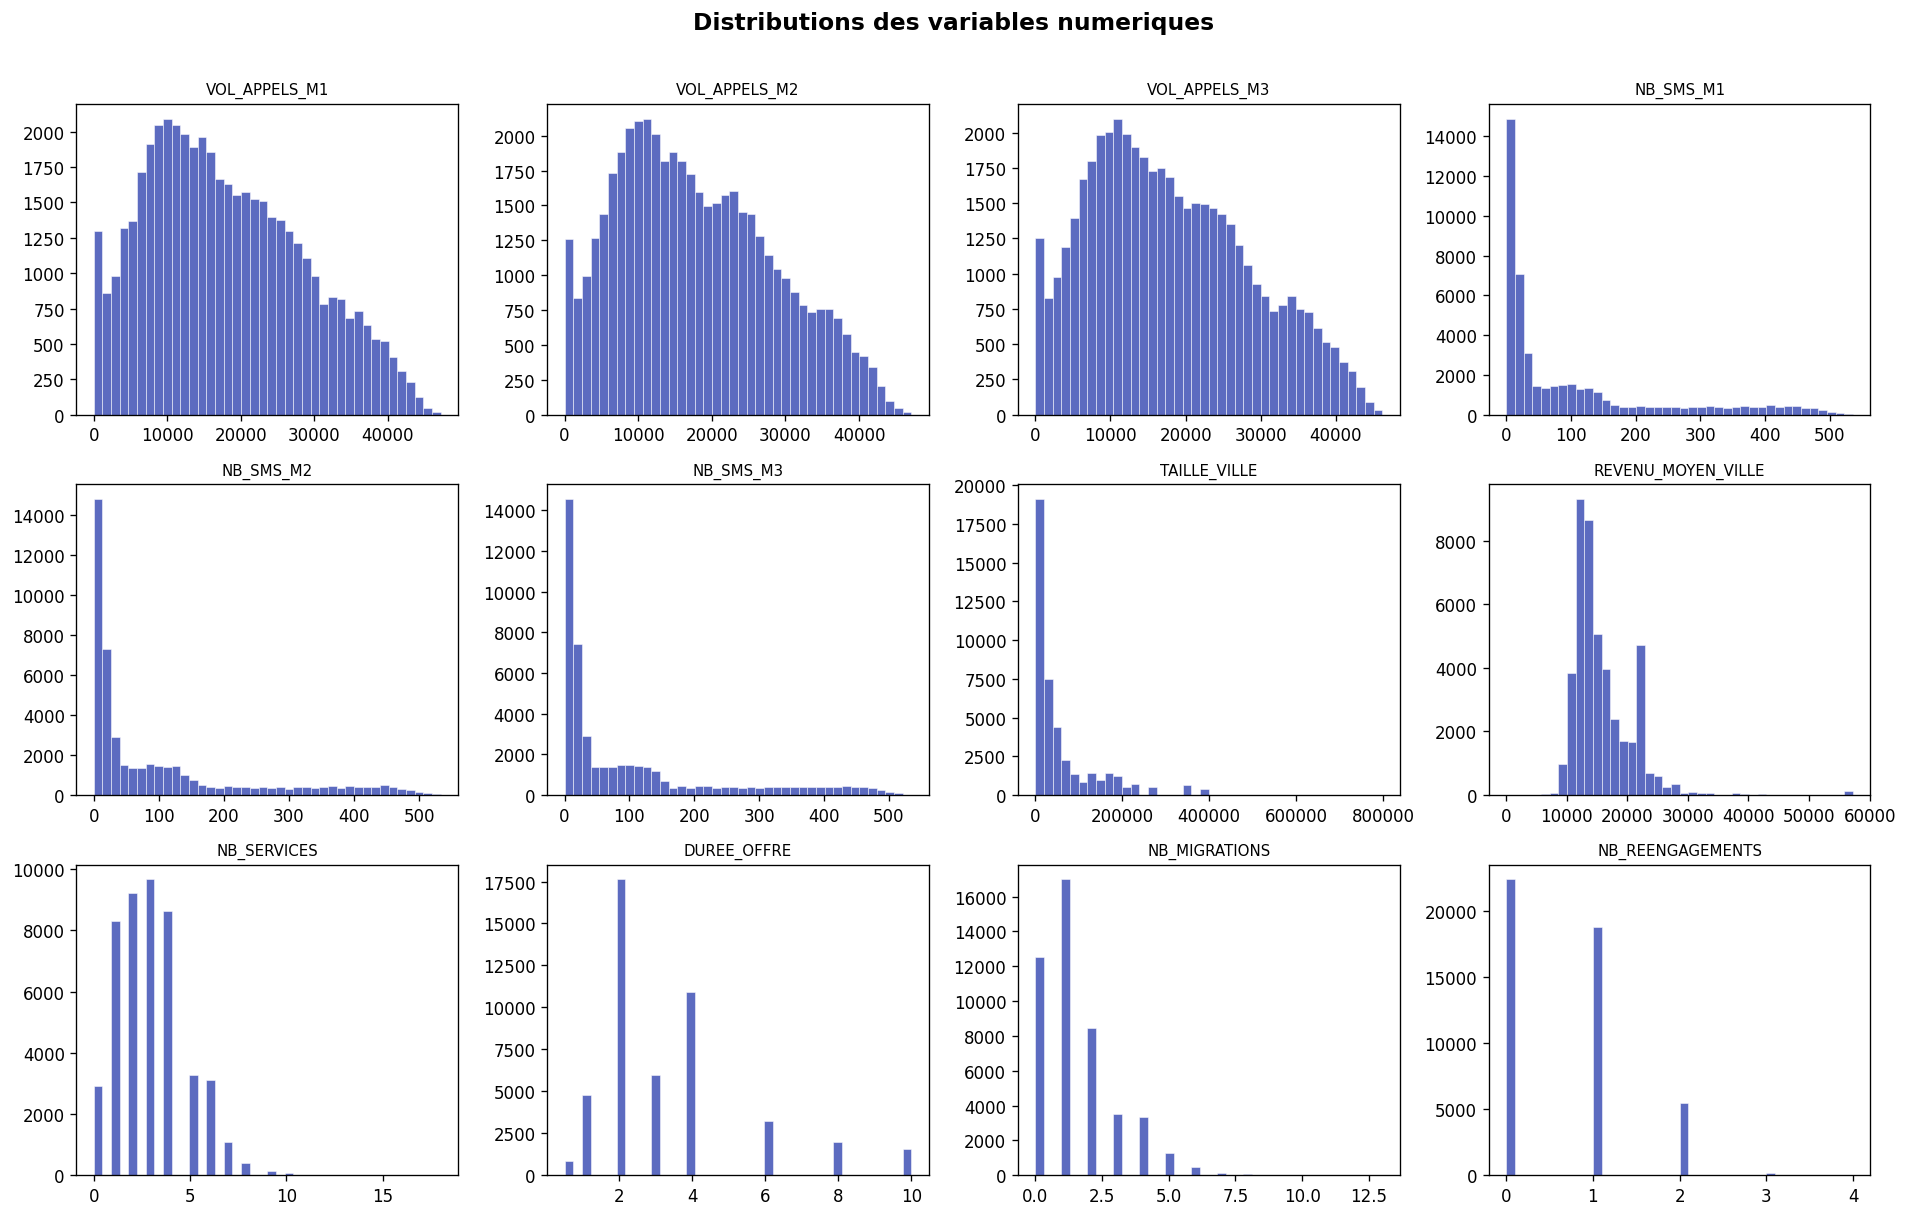

In [6]:
# Variables numeriques : distribution
num_cols = ['VOL_APPELS_M1','VOL_APPELS_M2','VOL_APPELS_M3',
            'NB_SMS_M1','NB_SMS_M2','NB_SMS_M3',
            'TAILLE_VILLE','REVENU_MOYEN_VILLE','NB_SERVICES',
            'DUREE_OFFRE','NB_MIGRATIONS','NB_REENGAGEMENTS']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        axes[i].hist(df[col].dropna(), bins=40, color='#5C6BC0', edgecolor='white', linewidth=0.3)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('')
plt.suptitle('Distributions des variables numeriques', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'distributions_numeriques.png', bbox_inches='tight')
plt.show()

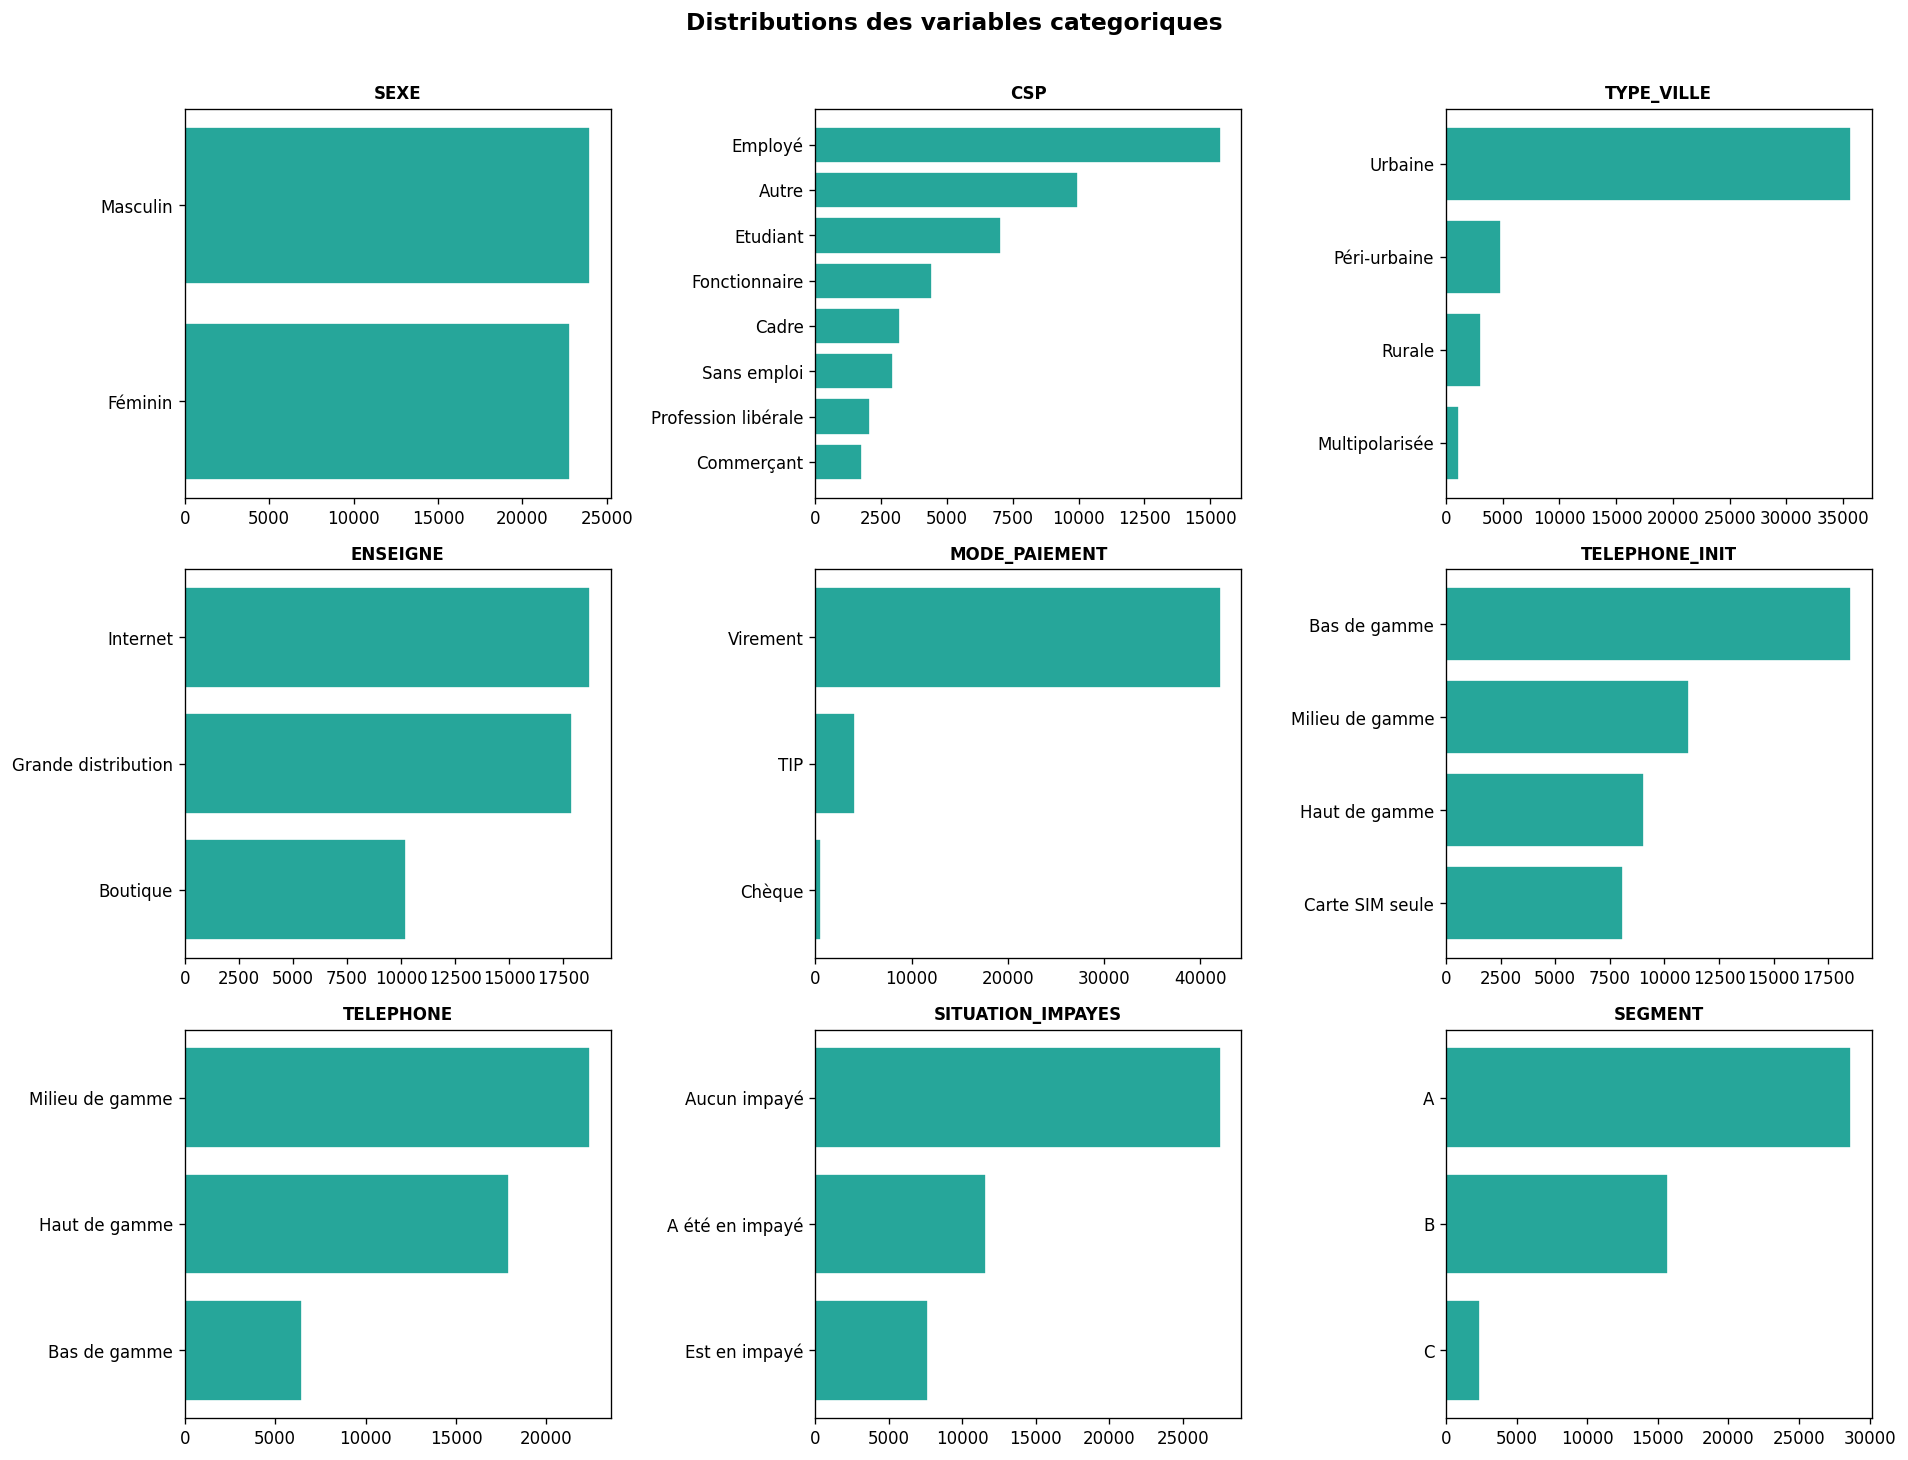

In [7]:
# Variables categoriques
cat_cols = ['SEXE', 'CSP', 'TYPE_VILLE', 'ENSEIGNE', 'MODE_PAIEMENT',
            'TELEPHONE_INIT', 'TELEPHONE', 'SITUATION_IMPAYES', 'SEGMENT']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    if col in df.columns:
        vc = df[col].value_counts().head(8)
        axes[i].barh(vc.index.astype(str), vc.values, color='#26A69A', edgecolor='white')
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].invert_yaxis()
plt.suptitle('Distributions des variables categoriques', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'distributions_categoriques.png', bbox_inches='tight')
plt.show()

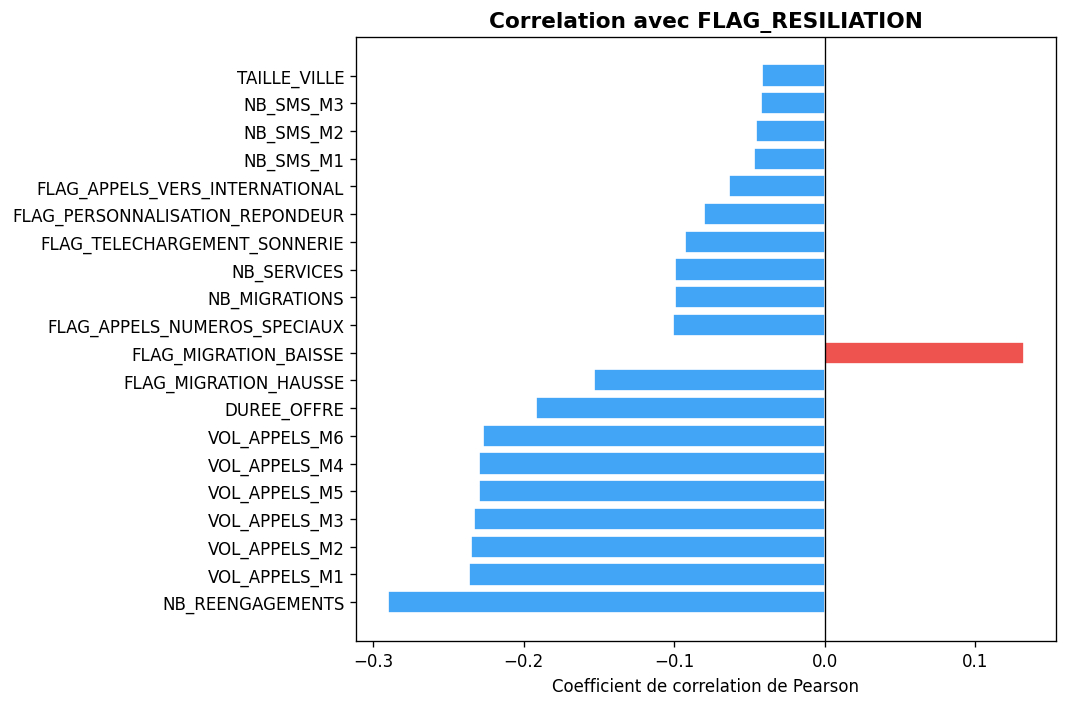

In [8]:
# Correlation numerique vs cible
df['FLAG_RESILIATION'] = pd.to_numeric(df['FLAG_RESILIATION'], errors='coerce')

vol_cols = [c for c in df.columns if 'VOL_APPELS' in c or 'NB_SMS' in c]
for c in vol_cols + ['TAILLE_VILLE','REVENU_MOYEN_VILLE','NB_SERVICES',
                      'DUREE_OFFRE','NB_MIGRATIONS','NB_REENGAGEMENTS',
                      'DUREE_OFFRE_INIT']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

corr_target = df.select_dtypes(include='number').corr()['FLAG_RESILIATION'].drop('FLAG_RESILIATION')
corr_target = corr_target.sort_values(key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#EF5350' if v > 0 else '#42A5F5' for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation avec FLAG_RESILIATION', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient de correlation de Pearson')
plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'correlation_cible.png', bbox_inches='tight')
plt.show()

## 3. Ingenierie des attributs et nettoyage

In [9]:
df_clean = df.copy()

# --- Suppression colonne identifiant ---
df_clean.drop(columns=['ID_CLIENT'], errors='ignore', inplace=True)

# --- Parsing des dates et calcul d'attributs derives ---
from datetime import datetime

REFERENCE_DATE = pd.Timestamp('2019-12-01')

for date_col in ['DATE_NAISSANCE', 'DATE_ACTIVATION', 'DATE_FIN_ENGAGEMENT',
                  'DATE_DERNIER_REENGAGEMENT']:
    if date_col in df_clean.columns:
        df_clean[date_col] = pd.to_datetime(df_clean[date_col], format='%d/%m/%Y', errors='coerce')

# Age du client
df_clean['AGE'] = ((REFERENCE_DATE - df_clean['DATE_NAISSANCE']).dt.days / 365.25).round(1)
df_clean['AGE'] = df_clean['AGE'].clip(lower=0, upper=100)

# Anciennete en mois depuis activation
df_clean['ANCIENNETE_MOIS'] = ((REFERENCE_DATE - df_clean['DATE_ACTIVATION']).dt.days / 30.44).round(1)
df_clean['ANCIENNETE_MOIS'] = df_clean['ANCIENNETE_MOIS'].clip(lower=0)

# Jours restants avant fin engagement
df_clean['JOURS_FIN_ENGAGEMENT'] = (df_clean['DATE_FIN_ENGAGEMENT'] - REFERENCE_DATE).dt.days
# Negatif = engagement expire
df_clean['ENGAGEMENT_EXPIRE'] = (df_clean['JOURS_FIN_ENGAGEMENT'] < 0).astype(int)

# Suppression colonnes de dates brutes
df_clean.drop(columns=['DATE_NAISSANCE','DATE_ACTIVATION','DATE_FIN_ENGAGEMENT',
                        'DATE_DERNIER_REENGAGEMENT'], inplace=True, errors='ignore')

# Volume moyen d'appels sur 6 mois
vol_cols = ['VOL_APPELS_M1','VOL_APPELS_M2','VOL_APPELS_M3',
            'VOL_APPELS_M4','VOL_APPELS_M5','VOL_APPELS_M6']
df_clean['VOL_APPELS_MOY'] = df_clean[vol_cols].mean(axis=1)

# Tendance appels (M1 vs M6)
df_clean['TENDANCE_APPELS'] = df_clean['VOL_APPELS_M1'] - df_clean['VOL_APPELS_M6']

# Volume moyen SMS
sms_cols = ['NB_SMS_M1','NB_SMS_M2','NB_SMS_M3',
            'NB_SMS_M4','NB_SMS_M5','NB_SMS_M6']
df_clean['NB_SMS_MOY'] = df_clean[sms_cols].mean(axis=1)
df_clean['TENDANCE_SMS'] = df_clean['NB_SMS_M1'] - df_clean['NB_SMS_M6']

print(f"Dimensions apres ingenierie : {df_clean.shape}")
df_clean[['AGE','ANCIENNETE_MOIS','VOL_APPELS_MOY','TENDANCE_APPELS']].describe()

Dimensions apres ingenierie : (46842, 45)


,AGE,ANCIENNETE_MOIS,VOL_APPELS_MOY,TENDANCE_APPELS
count,46798.000000,46842.000000,46842.000000,46842.000000
mean,38.191621,28.937550,17978.425074,33.740874
std,12.876017,17.652347,10477.366260,2106.430869
min,17.900000,-0.000000,0.000000,-9897.000000
25%,27.700000,13.800000,9610.333333,-995.000000
50%,35.900000,28.100000,16696.000000,0.000000
75%,47.100000,41.800000,25391.375000,1068.750000
max,92.000000,85.200000,45954.666667,9832.000000


## 4. Gestion des valeurs manquantes

In [10]:
from sklearn.impute import SimpleImputer

# Apercu des manquants apres ingenierie
miss2 = df_clean.isnull().sum()
print("Colonnes avec valeurs manquantes :")
print(miss2[miss2 > 0].sort_values(ascending=False).to_string())

Colonnes avec valeurs manquantes :
TAILLE_VILLE            3636
TYPE_VILLE              1992
REVENU_MOYEN_VILLE      1992
JOURS_FIN_ENGAGEMENT     635
NB_SMS_M3                443
AGE                       44
SEXE                       7


In [11]:
# Imputation des numeriques par la mediane
num_cols_clean = df_clean.select_dtypes(include='number').columns.tolist()
num_cols_clean = [c for c in num_cols_clean if c != 'FLAG_RESILIATION']

for col in num_cols_clean:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# Imputation des categoriques par le mode
cat_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()
for col in cat_cols_clean:
    mode_val = df_clean[col].mode()
    if len(mode_val) > 0:
        df_clean[col] = df_clean[col].fillna(mode_val[0])

# Verification
remaining_miss = df_clean.isnull().sum().sum()
print(f"Valeurs manquantes restantes : {remaining_miss}")

Valeurs manquantes restantes : 0


## 5. Encodage des variables categoriques

In [12]:
from sklearn.preprocessing import LabelEncoder

# Encodage label pour variables ordinales naturelles
ordinal_map = {
    'DUREE_OFFRE_INIT': None,  # numerique deja
    'SEGMENT': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
}

# SEGMENT
if 'SEGMENT' in df_clean.columns:
    df_clean['SEGMENT_NUM'] = df_clean['SEGMENT'].map(
        lambda x: ord(str(x)[0]) - ord('A') if pd.notnull(x) else -1
    )
    df_clean.drop(columns=['SEGMENT'], inplace=True)

# Reduction de la cardinalite du code postal -> departement (2 premiers chiffres)
if 'CODE_POSTAL' in df_clean.columns:
    df_clean['CODE_POSTAL'] = df_clean['CODE_POSTAL'].astype(str).str.zfill(5)
    df_clean['DEPARTEMENT'] = df_clean['CODE_POSTAL'].str[:2].astype(str)
    df_clean.drop(columns=['CODE_POSTAL'], inplace=True)
    print(f"CODE_POSTAL -> DEPARTEMENT : {df_clean['DEPARTEMENT'].nunique()} departements uniques")

# One-hot encoding pour variables nominales (cardinalite raisonnable <= 50)
cat_remaining = df_clean.select_dtypes(include='object').columns.tolist()
high_card = [c for c in cat_remaining if df_clean[c].nunique() > 50]
if high_card:
    print(f"Suppression colonnes haute cardinalite : {high_card}")
    df_clean.drop(columns=high_card, inplace=True)
    cat_remaining = [c for c in cat_remaining if c not in high_card]
print(f"Colonnes categoriques a encoder : {cat_remaining}")

df_clean = pd.get_dummies(df_clean, columns=cat_remaining, drop_first=True, dtype=int)

print(f"Dimensions apres encodage : {df_clean.shape}")
df_clean.head(2)

CODE_POSTAL -> DEPARTEMENT : 100 departements uniques
Suppression colonnes haute cardinalite : ['DEPARTEMENT']
Colonnes categoriques a encoder : ['SEXE', 'CSP', 'TYPE_VILLE', 'ENSEIGNE', 'MODE_PAIEMENT', 'TELEPHONE_INIT', 'TELEPHONE', 'SITUATION_IMPAYES']
Dimensions apres encodage : (46842, 58)


,FLAG_RESILIATION,TAILLE_VILLE,REVENU_MOYEN_VILLE,DUREE_OFFRE_INIT,DUREE_OFFRE,NB_MIGRATIONS,FLAG_MIGRATION_HAUSSE,FLAG_MIGRATION_BAISSE,NB_SERVICES,FLAG_PERSONNALISATION_REPONDEUR,...,ENSEIGNE_Internet,MODE_PAIEMENT_TIP,MODE_PAIEMENT_Virement,TELEPHONE_INIT_Carte SIM seule,TELEPHONE_INIT_Haut de gamme,TELEPHONE_INIT_Milieu de gamme,TELEPHONE_Haut de gamme,TELEPHONE_Milieu de gamme,SITUATION_IMPAYES_Aucun impayé,SITUATION_IMPAYES_Est en impayé
0,1,16715.0,24035.0,4.0,2.0,1,0,1,3,0,...,0,0,1,1,0,0,0,1,1,0
1,1,515.0,14152.0,4.0,2.0,1,0,1,1,0,...,1,0,1,0,0,1,0,0,1,0


## 6. Gestion du desequilibre de classes (SMOTE)

In [13]:
from collections import Counter
from imblearn.over_sampling import SMOTE

X = df_clean.drop(columns=['FLAG_RESILIATION'])
y = df_clean['FLAG_RESILIATION'].astype(int)

print(f"Distribution avant SMOTE : {Counter(y)}")
print(f"Ratio : {Counter(y)[0]/Counter(y)[1]:.2f}:1")

# Application SMOTE uniquement sur le train (le split se fait au notebook 3)
# On sauvegarde X et y tels quels — SMOTE sera applique dans le pipeline de modelisation
print(f"\nDimensions X : {X.shape}")
print(f"Colonnes : {X.shape[1]} attributs")

Distribution avant SMOTE : Counter({0: 38438, 1: 8404})
Ratio : 4.57:1

Dimensions X : (46842, 57)
Colonnes : 57 attributs


## 7. Normalisation (Min-Max)

In [14]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Colonnes numeriques continues (pas les flags binaires)
binary_cols = [c for c in X.columns if X[c].nunique() == 2]
scale_cols  = [c for c in X.columns if c not in binary_cols and X[c].dtype in ['float64','int64']
               and X[c].nunique() > 2]

print(f"Colonnes a normaliser : {len(scale_cols)}")
print(f"Colonnes binaires     : {len(binary_cols)}")

scaler = MinMaxScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

# Sauvegarde du scaler pour le dashboard
joblib.dump(scaler, ROOT / 'models' / 'scaler.pkl')
joblib.dump(scale_cols, ROOT / 'models' / 'scale_cols.pkl')
print("Scaler sauvegarde.")

X_scaled.describe().round(3)

Colonnes a normaliser : 27
Colonnes binaires     : 30
Scaler sauvegarde.


,TAILLE_VILLE,REVENU_MOYEN_VILLE,DUREE_OFFRE_INIT,DUREE_OFFRE,NB_MIGRATIONS,FLAG_MIGRATION_HAUSSE,FLAG_MIGRATION_BAISSE,NB_SERVICES,FLAG_PERSONNALISATION_REPONDEUR,FLAG_TELECHARGEMENT_SONNERIE,...,ENSEIGNE_Internet,MODE_PAIEMENT_TIP,MODE_PAIEMENT_Virement,TELEPHONE_INIT_Carte SIM seule,TELEPHONE_INIT_Haut de gamme,TELEPHONE_INIT_Milieu de gamme,TELEPHONE_Haut de gamme,TELEPHONE_Milieu de gamme,SITUATION_IMPAYES_Aucun impayé,SITUATION_IMPAYES_Est en impayé
count,46842.000,46842.000,46842.000,46842.000,46842.000,46842.000,46842.000,46842.000,46842.000,46842.000,...,46842.00,46842.000,46842.000,46842.000,46842.000,46842.000,46842.000,46842.000,46842.000,46842.000
mean,0.070,0.274,0.283,0.291,0.113,0.356,0.503,0.164,0.194,0.136,...,0.40,0.088,0.900,0.173,0.193,0.238,0.383,0.479,0.589,0.164
std,0.095,0.085,0.139,0.220,0.111,0.479,0.500,0.102,0.396,0.343,...,0.49,0.284,0.301,0.378,0.395,0.426,0.486,0.500,0.492,0.370
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.009,0.219,0.158,0.158,0.000,0.000,0.000,0.111,0.000,0.000,...,0.00,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.032,0.248,0.263,0.263,0.077,0.000,1.000,0.167,0.000,0.000,...,0.00,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
75%,0.081,0.309,0.368,0.368,0.154,1.000,1.000,0.222,0.000,0.000,...,1.00,0.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.00,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 8. Sauvegarde des donnees prepares

In [15]:
# Sauvegarde
X_scaled.to_parquet(DATA_PROC / 'X_preprocessed.parquet', index=False)
y.to_frame().to_parquet(DATA_PROC / 'y_preprocessed.parquet', index=False)

# Sauvegarde de la liste des colonnes
import json
with open(DATA_PROC / 'feature_names.json', 'w') as f:
    json.dump(X_scaled.columns.tolist(), f, indent=2)

print(f"X shape : {X_scaled.shape}")
print(f"y shape : {y.shape}")
print(f"\nDistribution finale y :")
print(y.value_counts(normalize=True).map(lambda x: f'{x:.1%}'))
print("\nDonnees sauvegardees dans data/processed/")

X shape : (46842, 57)
y shape : (46842,)

Distribution finale y :
FLAG_RESILIATION
0    82.1%
1    17.9%
Name: proportion, dtype: str

Donnees sauvegardees dans data/processed/


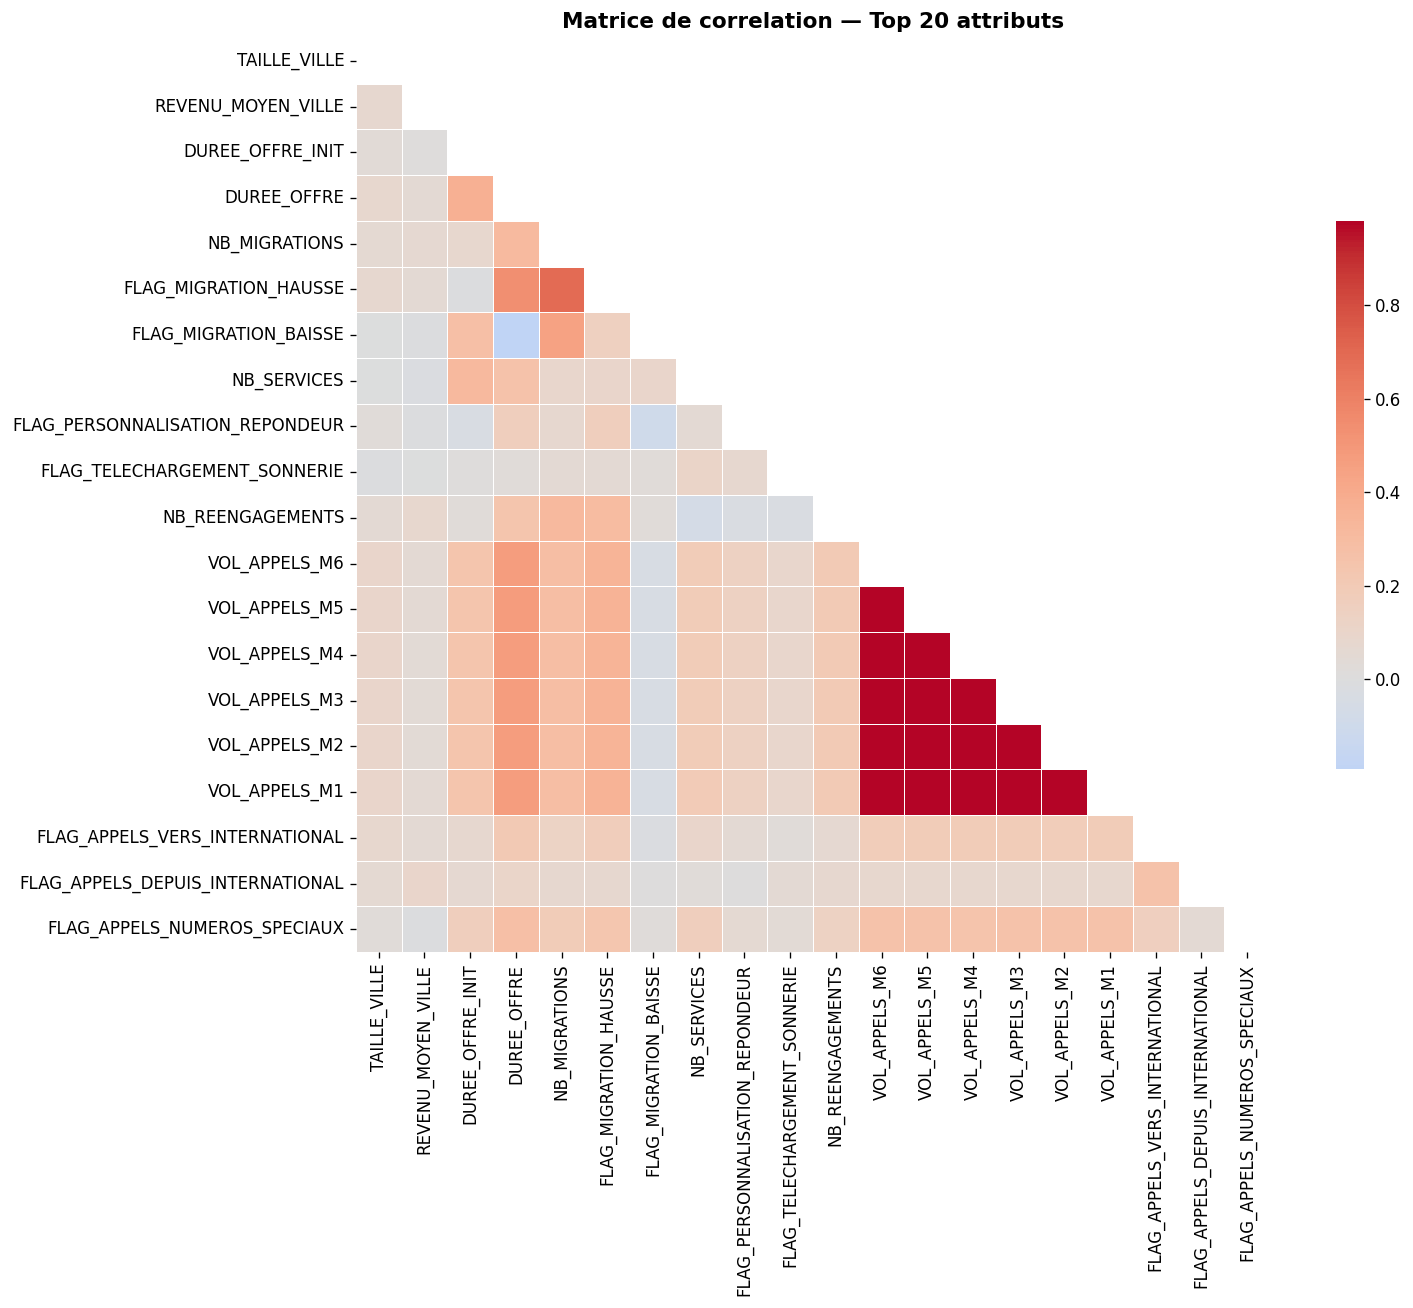

Preparation terminee.


In [16]:
# Matrice de correlation finale (top 20 features numeriques)
top_num = X_scaled.select_dtypes(include='number').columns[:20]
corr_matrix = X_scaled[top_num].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.6},
            ax=ax, annot=False)
ax.set_title('Matrice de correlation — Top 20 attributs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'matrice_correlation.png', bbox_inches='tight')
plt.show()
print("Preparation terminee.")